# Exploratory Data Analysis (EDA Basics) Assignment

### Q1. What is the average, median, and standard deviation of house prices?

#### Answer:

In [2]:
import pandas as pd

In [3]:
# Loading dataset
df = pd.read_csv('House Price India.csv')

In [52]:
# Basic cheack
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14620 non-null  int64  
 1   Date                                   14620 non-null  int64  
 2   number of bedrooms                     14620 non-null  int64  
 3   number of bathrooms                    14620 non-null  float64
 4   living area                            14620 non-null  int64  
 5   lot area                               14620 non-null  int64  
 6   number of floors                       14620 non-null  float64
 7   waterfront present                     14620 non-null  int64  
 8   number of views                        14620 non-null  int64  
 9   condition of the house                 14620 non-null  int64  
 10  grade of the house                     14620 non-null  int64  
 11  Ar

In [5]:
# Checking and handeling missing values 
df.isnull().sum()

id                                       0
Date                                     0
number of bedrooms                       0
number of bathrooms                      0
living area                              0
lot area                                 0
number of floors                         0
waterfront present                       0
number of views                          0
condition of the house                   0
grade of the house                       0
Area of the house(excluding basement)    0
Area of the basement                     0
Built Year                               0
Renovation Year                          0
Postal Code                              0
Lattitude                                0
Longitude                                0
living_area_renov                        0
lot_area_renov                           0
Number of schools nearby                 0
Distance from the airport                0
Price                                    0
dtype: int6

In [6]:
# Calculateing asked statistics
mean_price = df['Price'].mean()
median_price = df['Price'].median()
std_price = df['Price'].std()

# And Displaying results
print (" Mean of house prices : ",mean_price ) 
print (" Median of house prices : ",median_price )
print (" Standard deviation of house prices : ",std_price )

 Mean of house prices :  538932.2183310534
 Median of house prices :  450000.0
 Standard deviation of house prices :  367532.3808039669


### Q2. Which number of bedrooms is most common?

#### Answer:

In [14]:
# 1. Checking value counts of bedrooms
bedroom_counts = df['number of bedrooms'].value_counts()
print("Bedroom counts:\n", bedroom_counts)

Bedroom counts:
 number of bedrooms
3     6612
4     4724
2     1844
5     1079
6      176
1      136
7       30
8       11
9        3
10       3
33       1
11       1
Name: count, dtype: int64


In [15]:
# 2. The most common number of bedrooms type is:
most_common_bedrooms = df['number of bedrooms'].mode()[0]
print("\nMost common number of bedrooms:", most_common_bedrooms)


Most common number of bedrooms: 3


### Q3. Check if the price data is skewed.

#### Answer:

In [16]:
# 1. Checking skewness of Price column
price_skewness = df['Price'].skew()
print("Skewness of Price data:", price_skewness)

Skewness of Price data: 4.269297720707117


### Conclusion:

The data is **heavily right-skewed**, which indicates the presence of luxury properties.

### Q4. What is the average price for each number of bedrooms?

#### Answer:

In [24]:
# 1. Grouping by Bedrooms and calculateing average price to display average price for each number of bedrooms.
avg_price_by_bedrooms = df.groupby('number of bedrooms')['Price'].mean()
print ("Average price for each", avg_price_by_bedrooms)

Average price for each number of bedrooms
1     3.089638e+05
2     3.985476e+05
3     4.632776e+05
4     6.361988e+05
5     7.752550e+05
6     8.375815e+05
7     1.016544e+06
8     1.208455e+06
9     7.766663e+05
10    8.200000e+05
11    5.200000e+05
33    6.400000e+05
Name: Price, dtype: float64


### Q5.  What is the relationship between living area and price? (Use : Area without Basement).

#### Answer:

In [28]:
import matplotlib.pyplot as plt

# 1. Calculateing correlation
correlation = df['Area of the house(excluding basement)'].corr(df['Price'])
print("Correlation between Area without Basement and Price:", correlation)

Correlation between Area without Basement and Price: 0.6152204198678111


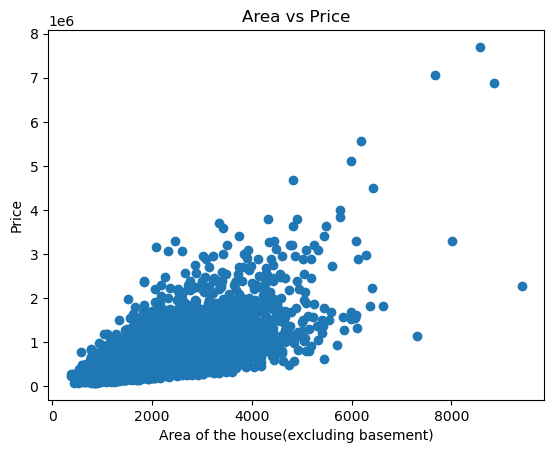

In [29]:
# 2. Scatter plot for better understanding of data
plt.scatter(df['Area of the house(excluding basement)'], df['Price'])
plt.xlabel("Area of the house(excluding basement)")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

### Conclusion:
- As the living area increases, the price also increases
- The value is around **0.6**, which indicates a **Moderately strong positive relationship**


### Q6. Identify any anomalies where houses have high prices but low areas.

#### Answer:
##### Approach:
- Find **High price** → Above 75th percentile (top 25%)
- and **Low area** → Below 25th percentile (bottom 25%)
- Filter such rows using pandas to identify properties that don't follow the general trend.

In [36]:
# Define thresholds, filtering anomalies and displaying result.
high_price_threshold = df['Price'].quantile(0.75)
low_area_threshold = df['Area of the house(excluding basement)'].quantile(0.25)
anomalies = df[(df['Price'] > high_price_threshold) & (df['Area of the house(excluding basement)'] < low_area_threshold)]
print (anomalies[['Price', 'Area of the house(excluding basement)', 'number of bedrooms']])

        Price  Area of the house(excluding basement)  number of bedrooms
101    657100                                   1050                   4
174    675000                                    930                   2
176    650000                                   1160                   3
258    690000                                    980                   3
353    712000                                   1150                   3
...       ...                                    ...                 ...
14024  930000                                   1000                   2
14034  664950                                    780                   2
14277  650000                                   1080                   3
14482  659000                                    780                   2
14578  875000                                   1160                   3

[139 rows x 3 columns]


##### so the number of anomalies is : 139

### Q7. Compare average price based on number of floors and houses with or without waterfront.

#### Answer: 

In [51]:
# 1. Creating a pivot compare average price based on number of floors and houses with or without waterfront. ( with = 1, without = 0 )
pivot_table = df.pivot_table(
    values='Price',
    index='number of floors',
    columns='waterfront present',
    aggfunc='mean')

pivot_table

waterfront present,0,1
number of floors,,
1.0,4.323724e+05,1.211081e+06
1.5,5.476162e+05,1.232507e+06
2.0,6.357742e+05,2.075931e+06
2.5,1.087654e+06,3.280000e+06
3.0,5.558095e+05,1.655000e+06
3.5,1.205875e+06,NaN


#### Conclusion:
- Houses with waterfront are consistently 2x–3x more expensive.
- Floors contribute to price, but not as strongly as waterfront.

### Q8. Identify the minimum and maximum house price. What does this indicate?

#### Answe:

In [41]:
min_price = df['Price'].min()
print("Minimum house price:", min_price)

Minimum house price: 78000


In [42]:
max_price = df['Price'].max()
print("Maximum house price:", max_price)

Maximum house price: 7700000


#### Key Indications:
- The dataset contains both **low-end and luxury properties**
- High variation in prices indicates presence of a **diverse housing market**

### Q9. Which location (zipcode/area) has the highest average price?

#### Answer:

In [47]:
# 1. Calculateing average price per location
avg_price_by_location = df.groupby('Postal Code')['Price'].mean()
avg_price_by_location

Postal Code
122003    8.503290e+05
122004    8.398533e+05
122005    6.389622e+05
122006    6.136386e+05
122007    5.728347e+05
              ...     
122068    3.153815e+05
122069    4.812247e+05
122070    2.799618e+05
122071    2.348311e+06
122072    2.342158e+05
Name: Price, Length: 70, dtype: float64

In [50]:
# 2. Looking for location with highest average price and highest average price
highest_price_location = avg_price_by_location.idxmax()
highest_avg_price = avg_price_by_location.max()
print("Highest average price:", highest_avg_price)
print("Location code with highest average price:", highest_price_location)

Highest average price: 2348310.810810811
Location code with highest average price: 122071


### Q10. Write at least 5 insights from your analysis.

### Answer :
##### Based analysis the following key insights can be drawn:

##### 1: Price Distribution is Highly Skewed
The skewness value (~ 4.27) shows that the data is heavily right-skewed a few very expensive houses significantly increase the average price.


##### 2: Number of Bedrooms Impacts Price
As the number of bedrooms increases, the average house price generally increases however, extreme values (like 33 bedrooms) indicate possible outliers or data issues.


##### 3: Living Area Strongly Influences Price
Correlation between area and price (~0.61) shows a moderately strong positive relationship.


##### 4: Waterfront Properties are Much More Expensive
Houses with waterfront have significantly higher prices (often 2–3x more).


##### 5: Wide Price Range Indicates High Variability
Prices range is from 78,000 to 7,700,000 this indicates presence of both low-cost and luxury properties and high variation in the dataset.


##### 6: Location Plays a Key Role
Certain postal codes have much higher average prices which indicates that location is a critical factor in determining house price.
